In [16]:
import importlib
import sys
sys.path.append('../code')

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd

import SeaLevelContrib as slc

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

In [17]:
importlib.reload(slc)

<module 'SeaLevelContrib' from 'C:\\Users\\kyrab\\Github\\SLBudget\\notebooks\\../code\\SeaLevelContrib.py'>

In [18]:
def rotate_longitude(ds):
    '''Rotate the longitude of an xarray dataset from [0,360] to [-180,180]'''
    
    if 'lon' in ds.dims:
        lon = 'lon'
    elif 'longitude' in ds.dims:
        lon = 'longitude'
    else:
        print('Longitude not found in dimensions')
        
    ds[lon] = np.where(ds[lon]>180, ds[lon]-360, ds[lon])
    ds = ds.reindex({ lon : np.sort(ds[lon])})
    
    return ds


In [55]:
fred_dir = '../data/Frederikse2020/'
Fred_ant_ds = xr.open_dataset(f'{fred_dir}AIS.nc')
#Fred_ant_ds['AIS_rsl_mean'].isel(time=-1).plot()
#plt.show()

fred2 = rotate_longitude(Fred_ant_ds)
#display(fred2)
#fred2['AIS_rsl_mean'].isel(time=-1).plot()
#plt.show()
Gravis_dir = '../outputs/Gravis_Antarctica/'
Gravis_ant_ds = xr.open_dataset(f'{Gravis_dir}Gravis_Ant.nc')
display(Gravis_ant_ds)

<xarray.Dataset> Size: 12MB
Dimensions:     (time: 23, lat: 180, lon: 360)
Coordinates:
  * lon         (lon) float64 3kB 0.5 1.5 2.5 3.5 ... 356.5 357.5 358.5 359.5
  * lat         (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * time        (time) int64 184B 2002 2003 2004 2005 ... 2021 2022 2023 2024
Data variables:
    AIS_Gravis  (time, lat, lon) float64 12MB ...
Attributes:
    Info:     Based on Gravis data and created using the gravity toolkit

In [72]:
tg_id = [20, 22, 23, 24, 25, 32]
#Extract latitude and longitude from a tide gauge station from the list. 
tg_coord = slc.tg_lat_lon(tg_id[0])
print(tg_coord)

TWS = slc.contrib_frederikse2020(tg_coord, 'tws', extrap=True)
ANT = slc.contrib_frederikse2020(tg_coord, 'AIS', extrap=True)
GRE = slc.contrib_frederikse2020(tg_coord, 'GrIS', extrap=True)
GLA = slc.contrib_frederikse2020(tg_coord, 'glac', extrap=True)

glo_steric_df = slc.contrib_frederikse2020_glob('GloSteric', extrap=True)


ds = Gravis_ant_ds
sel_da = ds['AIS_Gravis'].ffill('lon', 3).bfill('lon', 3)
# Convert from mm to cm not needed because is already in cm

loc_da = sel_da.sel(lat = tg_coord[0], 
                    lon = tg_coord[1], 
                    method = 'nearest')

fr_name = {'tws' : 'TWS', 
       'AIS' : 'Antarctica', 
       'GrIS' : 'Greenland', 
       'glac' : 'Glaciers',
          'grav': 'Ant_gravis'}


GRAVANT = loc_da.squeeze().reset_coords(drop=True).to_dataframe(name=fr_name['grav'])    

''' 
EXTRAPOLATE OPTION
nby = 10
trend = np.polyfit(GRAVANT.index[-nby:], GRAVANT.iloc[-nby:], 1)
for i in range(7):
    GRAVANT.loc[GRAVANT.index.max() + 1] = (trend[1]+trend[0]*(GRAVANT.index.max()+1))
'''


(np.float64(51.442222), np.float64(3.596111))


' \nEXTRAPOLATE OPTION\nnby = 10\ntrend = np.polyfit(GRAVANT.index[-nby:], GRAVANT.iloc[-nby:], 1)\nfor i in range(7):\n    GRAVANT.loc[GRAVANT.index.max() + 1] = (trend[1]+trend[0]*(GRAVANT.index.max()+1))\n'

In [73]:
print(ANT)

#print(ANT.loc[2002])
print(ANT.loc[2002, "Antarctica"])

      Antarctica
time            
1900   -0.850000
1901   -0.845000
1902   -0.840000
1903   -0.835000
1904   -0.830000
...          ...
2021    0.480818
2022    0.527727
2023    0.574636
2024    0.621545
2025    0.668455

[126 rows x 1 columns]
-0.25


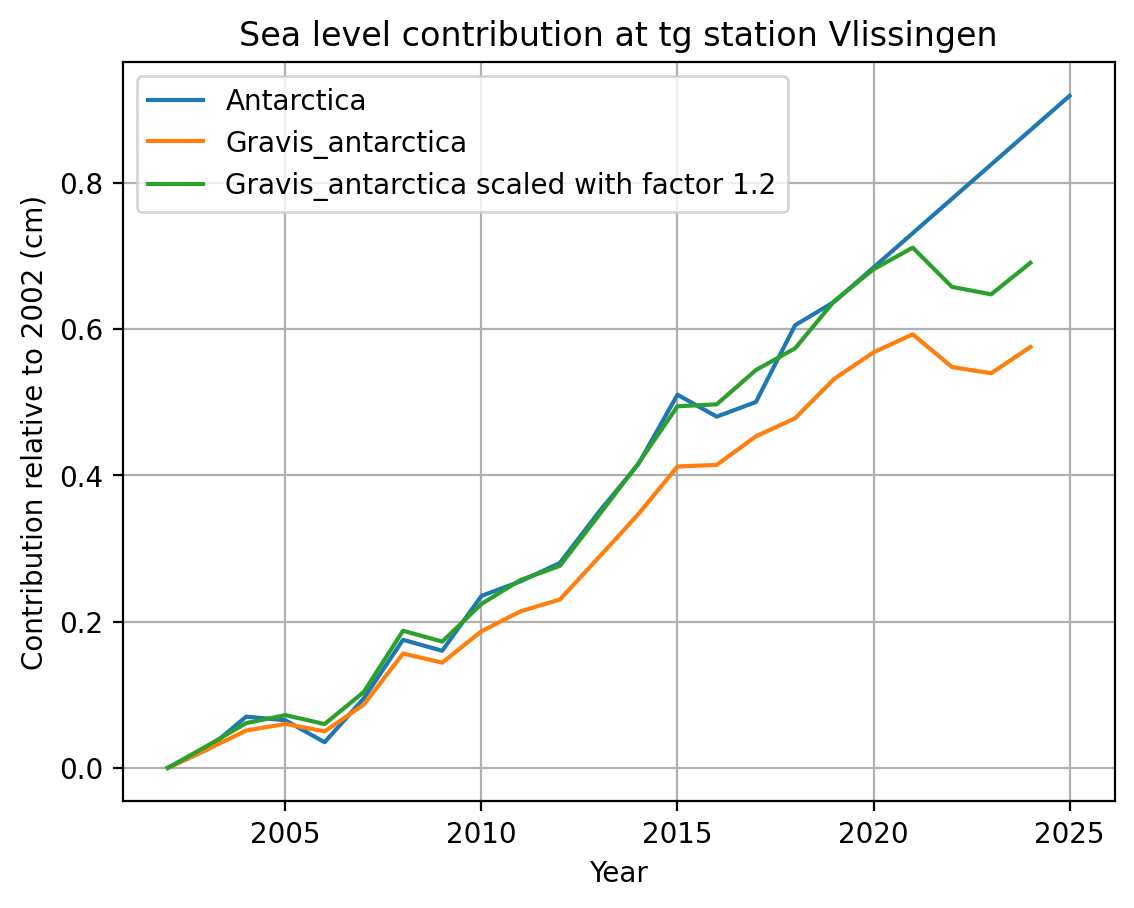

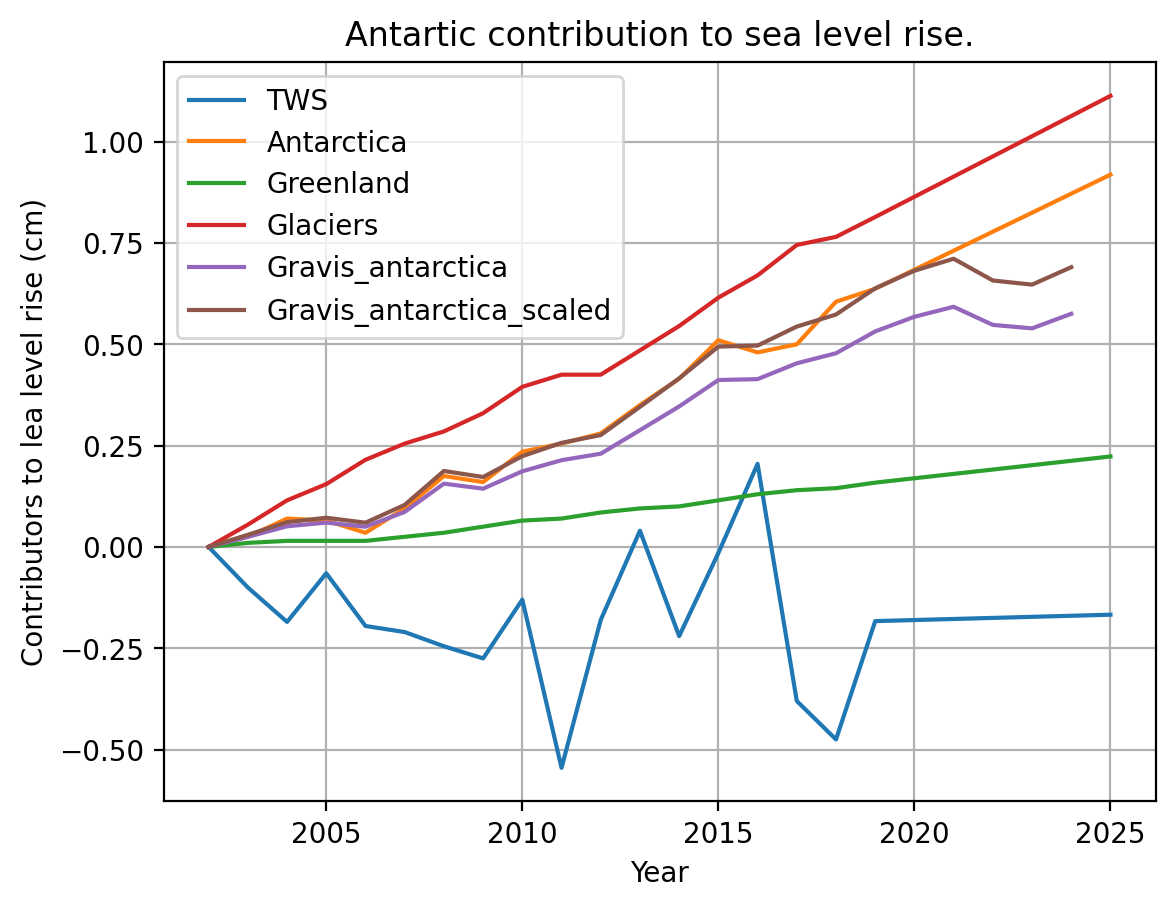

In [77]:
#plt.plot(TWS.loc[2000:], label='TWS')
plt.plot((ANT- ANT.loc[2002, "Antarctica"]).loc[2002:], label='Antarctica')
#plt.plot(GRE.loc[2000:], label='Greenland')
#plt.plot(GLA.loc[2000:], label='Glaciers')
plt.plot(GRAVANT.loc[2002:], label='Gravis_antarctica')
plt.plot(GRAVANT.loc[2002:]*1.2, label='Gravis_antarctica scaled with factor 1.2')
#plt.plot(glo_steric_df.loc[2000:], label='Global Steric')




plt.legend()
plt.xlabel('Year')
plt.title('Sea level contribution at tg station Vlissingen')
plt.ylabel('Contribution relative to 2002 (cm)')
plt.grid(True)
plt.show()




plt.plot((TWS-TWS.loc[2002, "TWS"]).loc[2002:], label='TWS')
plt.plot((ANT- ANT.loc[2002, "Antarctica"]).loc[2002:], label='Antarctica')
plt.plot((GRE-GRE.loc[2002, "Greenland"]).loc[2002:], label='Greenland')
plt.plot((GLA-GLA.loc[2002, "Glaciers"]).loc[2002:], label='Glaciers')
plt.plot(GRAVANT.loc[2002:], label='Gravis_antarctica')
plt.plot(GRAVANT.loc[2002:]*1.2, label='Gravis_antarctica_scaled')
#plt.plot((glo_steric_df-glo_steric_df.loc[2002, 'Global Steric']).loc[2002:], label='Global Steric')




plt.legend()
plt.xlabel('Year')
plt.ylabel('Contributors to lea level rise (cm)')
plt.title('Antartic contribution to sea level rise.')
plt.grid(True)
plt.show()
